>
> # Scenario analysis - Base scenario
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type
variable_1 = {"name": "base", "sym": "$A$", "int": False, "pos": 2}
variables = {"variable_1": variable_1}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variables["variable_1"]["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

In [4]:
# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [5]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,35,80.407565,35,193.213563,35,True
1,48,79.372193,21,242.668617,48,True
2,19,89.451480,36,202.520007,36,True
3,26,96.117268,39,210.635806,39,True
4,27,92.009076,23,219.360354,27,True


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 5/1 for scenario 75000.0


In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

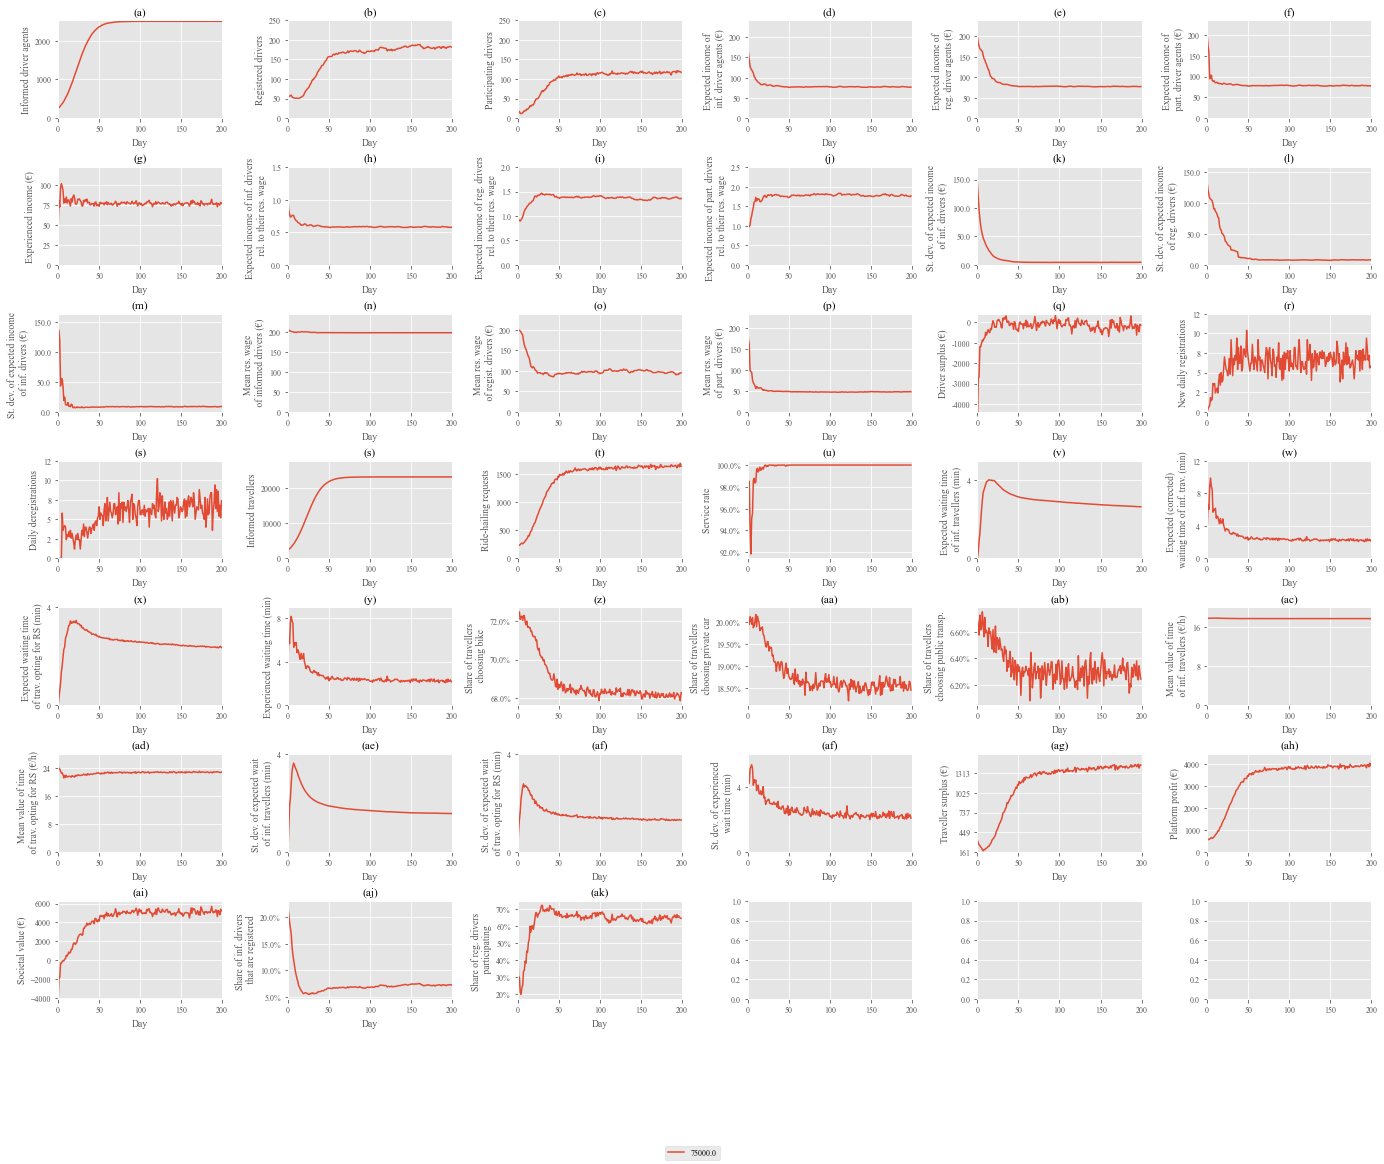

In [9]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], variables["variable_1"]["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [10]:
TINY_SIZE = 12
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TINY_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

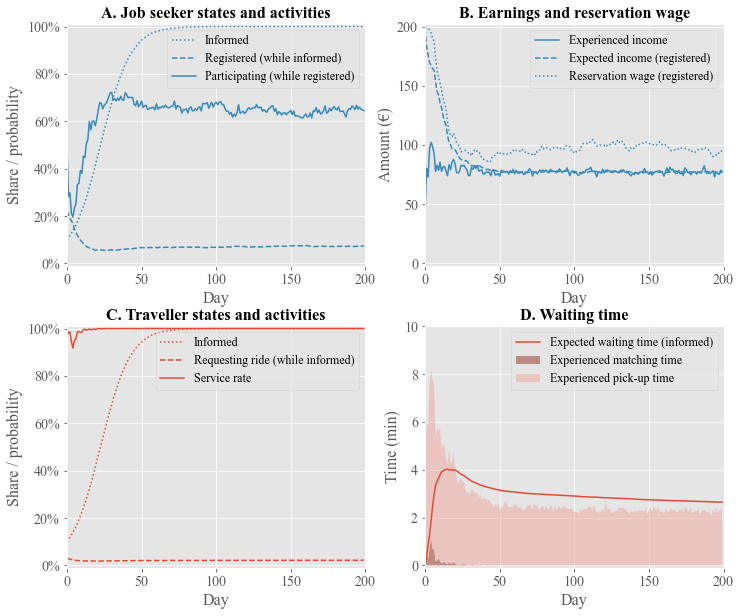

In [11]:
fig, axes = plt.subplots(2, 2, figsize = [12,10])
fig.subplots_adjust(hspace=.25, wspace=0.2, left=.12, right=.88)

axes[0, 0].plot(res_scn.sup.inform / 2500,linestyle='dotted',color="#348ABD")
axes[0, 0].plot(res_scn.sup.regist / res_scn.sup.inform, linestyle='dashed',color="#348ABD")
axes[0, 0].plot(res_scn.sup.particip / res_scn.sup.regist, linestyle='solid',color="#348ABD")
axes[0, 0].set_ylabel('Share / probability')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('A. Job seeker states and activities', weight='bold',fontsize=16)
axes[0, 0].set_xlim(left = 0, right = 200)
axes[0, 0].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 0].legend(['Informed','Registered (while informed)','Participating (while registered)'])
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[0, 1].plot(res_scn.sup.mean_exp_inc,linestyle='solid',color="#348ABD")
axes[0, 1].plot(res_scn.sup.mean_perc_inc_reg,linestyle='dashed',color="#348ABD")
axes[0, 1].plot(res_scn.sup.res_wage_reg,linestyle='dotted',color="#348ABD")
axes[0, 1].set_ylabel('Amount (€)')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('B. Earnings and reservation wage', weight='bold',fontsize=16)
axes[0, 1].set_xlim(left = 0, right = 200)
axes[0, 1].set_ylim(bottom = -2, top = 202)
axes[0, 1].legend(['Experienced income','Expected income (registered)','Reservation wage (registered)','Reservation wage (participating)'])

axes[1, 0].plot(res_scn.dem.inform / res_scn.dem.inform.max(),color='#E24A33',linestyle='dotted')
axes[1, 0].plot(res_scn.dem.requests / (res_scn.dem.inform * 75000 / res_scn.dem.inform.max()),color='#E24A33',linestyle='dashed')
axes[1, 0].plot(res_scn.dem.gets_offer, linestyle='solid',color='#E24A33')
axes[1, 0].set_ylabel('Share / probability')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('C. Traveller states and activities', weight='bold',fontsize=16)
axes[1, 0].set_xlim(left = 0, right = 200)
axes[1, 0].set_ylim(bottom = -0.01, top = 1.01)
axes[1, 0].legend(['Informed','Requesting ride (while informed)','Service rate'], loc='upper right')
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

df = res_scn.dem['match_time'][75000].copy().to_frame(name='match_time')
df['pickup_time'] = res_scn.dem['pickup_time'][75000]
df[df < 0] = 0
x = range(0,200)
y1 = df['match_time'] / 60
y2 = df['pickup_time'] / 60
colors = ["#9e3323","#f0a499"]
axes[1, 1].stackplot(x,y1,y2, alpha=0.5, colors=colors)
axes[1, 1].plot(res_scn.dem.perc_wait/60, linestyle='-',color="#e24a33")
axes[1, 1].set_ylabel('Time (min)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('D. Waiting time', weight='bold',fontsize=16)
axes[1, 1].set_xlim(left = 0, right = 200)
axes[1, 1].set_ylim(bottom = -0.1, top =10)
axes[1, 1].legend(['Expected waiting time (informed)','Experienced matching time','Experienced pick-up time'])

handles, labels = plt.gca().get_legend_handles_labels()

fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'evo.jpg'),dpi=300,bbox_inches='tight')

In [12]:
(res_scn.dem.requests / res_scn.dem.inform).head(10)
(res_scn.sup.regist / res_scn.sup.inform).head(25)
(res_scn.sup.particip / res_scn.sup.regist).head(25)
micro.dem.perc_wait[0] * micro.dem.requests[0]
micro.dem.requests[0][micro.dem.requests[0] == False] = np.nan

In [13]:
import osmnx as ox #OSM download and parse
G = ox.graph_from_place('Amsterdam, Netherlands', network_type='drive')

In [14]:
# loads graph and skim from a params paths
# if set_t:
#     _params = set_t0(_params)
skim_csv = 'C:\\Users\\arjanderuijter\\Programming\\MaaSSim\\data\\graphs\\Amsterdam.csv'

# _inData.G = ox.load_graphml(params[0].paths.G)
nodelos = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
skim = pd.read_csv(skim_csv, index_col='Unnamed: 0')
skim.columns = [int(c) for c in skim.columns]
# _inData.skim = skim
# _inData
skim

,6316199,46379627,46380013,46380094,46372441,46389218,46380483,46372472,46388842,46380482,...,439663488,46562430,46583853,1739504416,433807091,46571771,46581921,46540815,46540740,7890114045
6316199,0,42,86,123,206,225,233,244,267,273,...,14207,14233,14285,14345,14407,14803,15061,15254,15270,15680
25596477,4254,4212,4256,4293,4376,3948,4403,4414,3990,4443,...,16018,16044,16096,16156,16218,16614,16872,17065,17081,17491
25658579,4425,4467,4359,4397,4230,4650,4494,4268,4639,4534,...,16867,16894,16945,17006,17068,17464,17722,17914,17931,18341
26203121,2377,2419,2311,2348,2182,2406,2165,2220,2364,2205,...,12978,13004,13056,13117,13179,13575,13833,14025,14041,14451
26206556,2064,2106,1998,2036,1869,2218,1852,1907,2176,1892,...,13958,13985,14036,14097,14159,14555,14813,15005,15022,15432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8378814666,6450,6493,6384,6422,6256,6493,6520,6293,6535,6559,...,18563,18590,18641,18702,18764,19160,19418,19610,19627,20037
8378814667,6433,6475,6367,6404,6238,6475,6502,6276,6517,6542,...,18546,18572,18624,18684,18746,19142,19400,19592,19609,20019
8378814668,6481,6523,6415,6453,6286,6524,6550,6324,6566,6590,...,18594,18620,18672,18732,18794,19190,19448,19641,19657,20067
8378814669,6465,6508,6400,6437,6271,6508,6535,6309,6550,6575,...,18578,18605,18656,18717,18779,19175,19433,19625,19642,20052


In [15]:
# from moduleutils import load_G
# inData = load_G(inData, params[0], stats=True, set_t=False)  # download graph for the 'params.city' and calc the skim matrices

In [16]:
# # abc = os.path.abspath(os.path.join('maassim\\utils.py'))
# abc = 'C:\\Users\\arjanderuijter\\Programming\\MaaSSim\\maassim\\utils.py'
# abc
# from abc import load_G

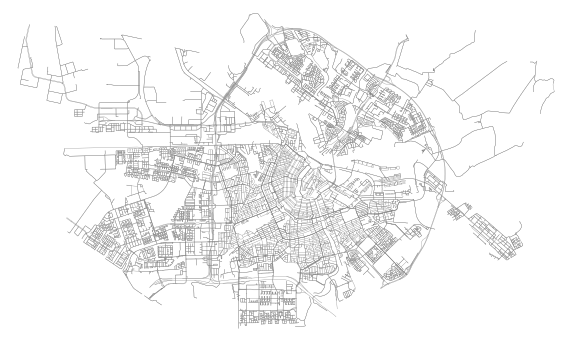

In [17]:
_ = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_linewidth=0.3,
                            show=False, close=False,
                            edge_color='grey', bgcolor='white')

In [18]:
import networkx as nx

In [19]:
abc = requests[0].copy()
abc['wait_time_195'] = micro.dem['wait_time'][0]['199']
abc['wait_time_196'] = micro.dem['wait_time'][0]['199']
abc['wait_time_197'] = micro.dem['wait_time'][0]['199']
abc['wait_time_198'] = micro.dem['wait_time'][0]['199']
abc['wait_time_199'] = micro.dem['wait_time'][0]['199']
abc['wait_time'] = abc[['wait_time_195','wait_time_196','wait_time_197','wait_time_198','wait_time_199']].mean(axis=1)
abc['perc_wait'] = micro.dem['perc_wait'][0]['199']
abc

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike,wait_time_195,wait_time_196,wait_time_197,wait_time_198,wait_time_199,wait_time,perc_wait
pax_id,,,,,,,,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,25.246984,-3.510941,-5.823855,-1.775200,NaN,NaN,NaN,NaN,NaN,NaN,308.593140
1,46429971,4837346311,2021-11-01 11:12:18,3532,2741.112123,10.522044,-2.566612,-3.250842,-0.821269,NaN,NaN,NaN,NaN,NaN,NaN,94.311798
2,7890114045,413562329,2021-11-01 17:56:29,12254,3263.899637,15.252714,-4.173784,-1597.870518,-4.131367,0.0,0.0,0.0,0.0,0.0,0.0,464.776276
3,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,34.284845,-4.207821,-6.383554,-2.706331,NaN,NaN,NaN,NaN,NaN,NaN,75.434700
4,5833554542,7997475204,2021-11-01 12:50:36,4402,2309.962509,26.980868,-3.870012,-8.496503,-2.624939,NaN,NaN,NaN,NaN,NaN,NaN,70.605598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23258,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,10.128432,-3.637799,-2.884601,-0.618104,NaN,NaN,NaN,NaN,NaN,NaN,65.938927
23259,1673410150,46329158,2021-11-01 12:21:45,3350,2508.837747,14.445231,-2.810218,-3.507253,-1.069990,NaN,NaN,NaN,NaN,NaN,NaN,228.490433
23260,46275357,2012191567,2021-11-01 13:36:23,2976,2065.121926,11.910865,-2.587919,-2.563650,-0.782186,NaN,NaN,NaN,NaN,NaN,NaN,130.227859


In [20]:
micro.sup.perc_inc[0]
micro.sup.regist[0]
df_regist = micro.sup.regist[0].copy()
df_regist[df_regist == False] = np.nan
df_perc_inc_reg = micro.sup.perc_inc[0] * df_regist
df_perc_inc_reg.head(20)

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
veh,,,,,,,,,,,,,,,,,,,,,
1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
bc = abc.groupby('origin', as_index=True)['wait_time'].mean()
bc = pd.DataFrame(bc)
cd = abc.groupby('origin', as_index=True)['perc_wait'].mean()
cd = pd.DataFrame(cd)

In [22]:
defg = drivers[0].copy()
defg['exp_inc'] = micro.sup['exp_inc'][0]['199']
defg['perc_inc'] = micro.sup['perc_inc'][0]['199']
df_2 = defg.groupby('pos', as_index=True)['exp_inc'].mean()
df_2 = pd.DataFrame(df_2)
df_3 = defg.groupby('pos', as_index=True)['perc_inc'].mean()
df_3 = pd.DataFrame(df_3)

In [23]:
node_list = list(G.nodes())
# nodes = G.nodes().to_numpy()
xyz = pd.DataFrame(index=node_list)
xyz['wait_time'] = np.nan
xyz.update(bc)
xyz[xyz['wait_time'] >= 0]
xyz = xyz['wait_time'].to_dict()
zab = pd.DataFrame(index=node_list)
zab['perc_wait'] = np.nan
zab.update(cd)
zab[zab['perc_wait'] >= 0]
zab = zab['perc_wait'].to_dict()
dfje = pd.DataFrame(index=node_list)
dfje['exp_wait'] = np.nan
dfje.update(df_2)
dfje = dfje.to_dict()
dfje_2 = pd.DataFrame(index=node_list)
dfje_2['perc_wait'] = np.nan
dfje_2.update(df_3)
dfje_2 = dfje_2.to_dict()

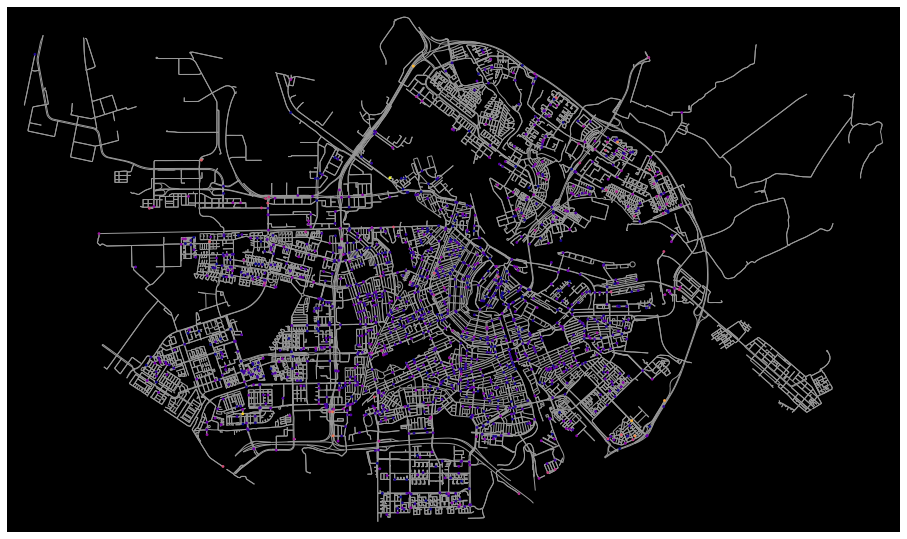

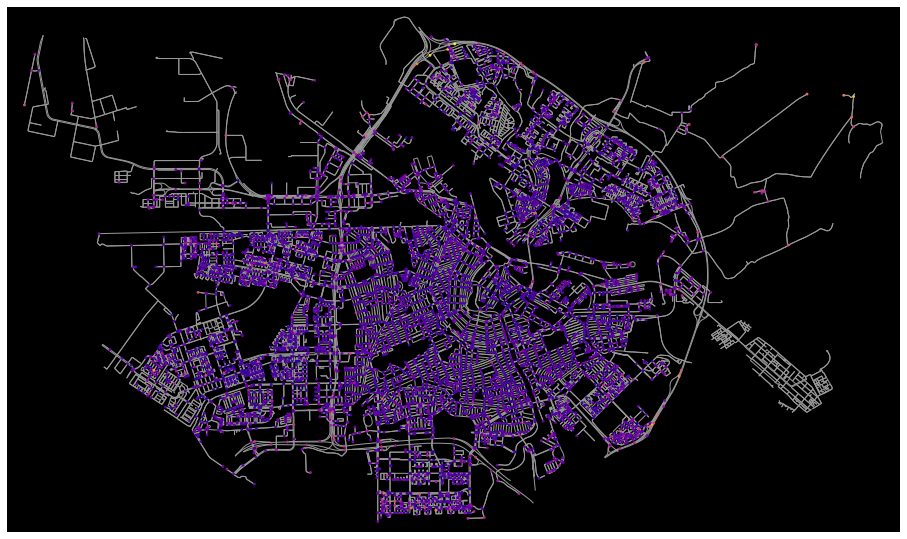

In [24]:
# calculate node betweenness centrality, weighted by travel time
# bc = nx.betweenness_centrality(D, weight="travel_time", normalized=True)
nx.set_node_attributes(G, values=xyz, name="bc")

# plot the graph, coloring nodes by betweenness centrality
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot_graph(
    G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))


nx.set_node_attributes(G, values=zab, name="cd")
nc = ox.plot.get_node_colors_by_attr(G, "cd", cmap="plasma")
fig, ax = ox.plot_graph(
    G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))

# nx.set_node_attributes(G, values=zab, name="dfje_2")
# nc = ox.plot.get_node_colors_by_attr(G, "cd", cmap="plasma")
# fig, ax = ox.plot_graph(
#     G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))

In [25]:
center_x = pd.DataFrame((G.nodes(data='x')))[1].mean()
center_y = pd.DataFrame((G.nodes(data='y')))[1].mean()

nearest = ox.distance.get_nearest_node(G, (center_y, center_x))

NameError: name 'variable' is not defined

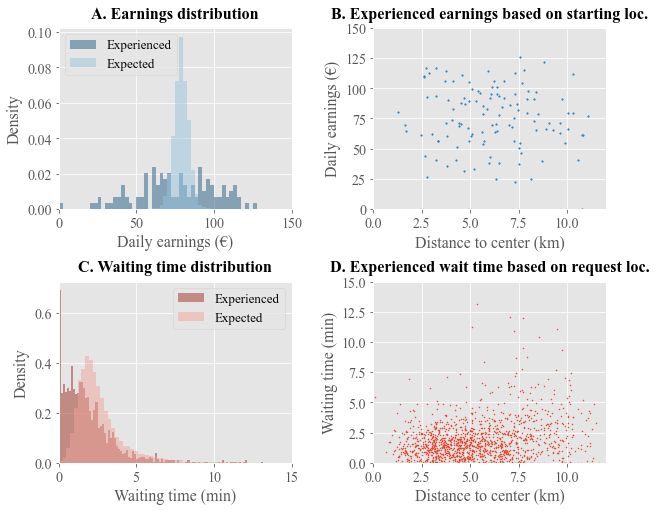

In [26]:
fig, axes = plt.subplots(2, 2, figsize = [10,8])
fig.subplots_adjust(hspace=.4, wspace=0.35, left=.12, right=.88)

micro.sup.exp_inc[0]['199'].loc[micro.sup.exp_inc[0]['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0],label='Experienced',color="#246084")
micro.sup.perc_inc[0]['199'].loc[micro.sup.perc_inc[0]['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0], label='Expected',color="#99c4de")
# df_perc_inc_reg['199'].loc[df_perc_inc_reg['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0], label='Expected reg')
axes[0,0].set_xlabel("Daily earnings (€)")
axes[0,0].set_xlim([0,150])
axes[0,0].set_ylabel("Density")
axes[0,0].set_title("A. Earnings distribution",weight='bold', pad=10, fontsize=16)
axes[0,0].legend(fontsize=13)

(micro.dem.wait_time[0]['199'].loc[micro.dem.wait_time[0]['199'] >= 0] / 60).hist(bins=100,density=True,alpha=0.5,ax=axes[1,0], label='Experienced',color="#9e3323")
(micro.dem.perc_wait[0]['199'].loc[micro.dem.perc_wait[0]['199'] >= 0] / 60).hist(bins=100,density=True,alpha=0.5,ax=axes[1,0], label='Expected',color="#f0a499")
abc = micro.dem.requests[0].copy()
abc[abc == False] = np.nan
micro.dem['perc_wait_req'][0] = micro.dem.perc_wait[0] * abc
axes[1, 0].set_xlabel("Waiting time (min)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlim([0, 15])
axes[1, 0].set_title("C. Waiting time distribution",weight='bold', pad=10, fontsize = 16)
axes[1, 0].legend(fontsize=13)

df_2['pos'] = df_2.index
df_2['dist_cent'] = df_2['pos'].apply(lambda x: skim[x][nearest] / 1000)
axes[0, 1].scatter(df_2['dist_cent'],df_2['exp_inc'],s=2.5,alpha=1,label='Experienced',color="#348abd")

bc['origin'] = bc.index
bc['dist_cent'] = bc['origin'].apply(lambda x: skim[x][nearest] / 1000)
axes[1, 1].scatter(bc['dist_cent'],bc['wait_time']/60,s=1,alpha=1,label='Experienced',color="#E24A33")

axes[0, 1].set_xlabel('Distance to center (km)')
axes[0, 1].set_ylabel('Daily earnings (€)')
axes[0, 1].set_title('B. Experienced earnings based on starting loc.', weight='bold', pad=10, fontsize=16)
axes[1, 1].set_ylabel('Waiting time (min)')
axes[1, 1].set_xlabel('Distance to center (km)')
axes[1, 1].set_title('D. Experienced wait time based on request loc.', weight='bold',pad=10, fontsize=16)
axes[1, 1].set_ylim(0,15)
axes[1, 1].set_xlim(0,12)
axes[0, 1].set_ylim(0,150)
axes[0, 1].set_xlim(0,12)
# axes[0, 1].legend(fontsize=13)
# axes[1, 1].legend(markerscale=8, fontsize=13)

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'hetero.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
# Compute modal share
eql_scn.dem['tot_pt'] = eql_scn.dem['pt'] + eql_scn.dem['extra_pt']
eql_scn.dem['tot_bike'] = eql_scn.dem['bike'] + eql_scn.dem['extra_bike']
eql_scn.dem['tot_car'] = eql_scn.dem['car'] + eql_scn.dem['extra_car']
tot_req = eql_scn.dem['tot_pt'] + eql_scn.dem['tot_bike'] + eql_scn.dem['tot_car'] + eql_scn.dem['requests']
eql_scn.dem['requests'] / tot_req

In [ ]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [ ]:
# Determine average VoT of travellers choosing different modes
kokos = requests[0].copy()
kokos['U_rs'] = -2.2497 + kokos['VoT'] * params[0]['evol']['travellers']['mode_pref']['beta_cost'] * (kokos['dist'] / params[0]['speeds']['ride'] / 3600) + 120/3600 * params[0]['evol']['travellers']['mode_pref']['wait_multip'] * kokos['VoT'] * params[0]['evol']['travellers']['mode_pref']['beta_cost'] + (1.5 + 1.5 * kokos['dist'] / 1000) * params[0]['evol']['travellers']['mode_pref']['beta_cost'] 
kokos['exp_car'] = np.exp(kokos['U_car'])
kokos['exp_pt'] = np.exp(kokos['U_pt'])
kokos['exp_bike'] = np.exp(kokos['U_bike'])
kokos['exp_rs'] = np.exp(kokos['U_rs'])
kokos['exp_sum'] = kokos['exp_car'] + kokos['exp_pt'] + kokos['exp_bike'] + kokos['exp_rs']
kokos['p_car'] = kokos['exp_car'] / kokos['exp_sum']
kokos['p_pt'] = kokos['exp_pt'] / kokos['exp_sum'] + kokos['p_car']
kokos['p_bike'] = kokos['exp_bike'] / kokos['exp_sum'] + kokos['p_pt']
# kokos['probs'] = kokos[['p_car','p_pt','p_bike']].values.tolist()
kokos['random_draw'] = np.random.random(len(kokos['U_rs']))
kokos['choice_car'] = kokos['random_draw'] < kokos['p_car']
kokos['choice_pt'] = ((1-kokos['choice_car']) * ( kokos['random_draw'] < kokos['p_pt'])).astype(bool)
kokos['choice_bike'] = ((1-kokos['choice_car']-kokos['choice_pt']) * ( kokos['random_draw'] < kokos['p_bike'])).astype(bool)
kokos['choice_rs'] = ((1 - kokos['choice_car'] - kokos['choice_pt'] - kokos['choice_bike'])).astype(bool)
kokos[kokos['choice_rs']]['VoT'].mean()
# kokos

---

In [38]:
# Mode shares in different replications of the simulation
eql_runs.dem[75000]

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
0,23263.0,1642.4,1.0,1642.4,148.118701,148.118701,156.597163,140.898235,15882.8,4298.0,...,152.098802,152.098802,76.502302,1407.066984,149.715967,-1.597265,NaN,38244.0,5141.0,6750.0
1,23422.0,1646.0,1.0,1646.0,130.952277,130.952277,162.648806,146.095346,15961.2,4337.6,...,123.601953,123.601953,78.264939,1461.107337,132.512783,-1.560507,NaN,38250.0,5018.0,6675.0
2,23187.0,1661.8,1.0,1661.8,138.821818,138.821818,157.569255,140.980754,15750.6,4310.0,...,134.410312,134.410312,77.501029,1468.210100,140.392223,-1.570405,NaN,38255.0,5113.0,6762.0
3,23259.0,1637.2,1.0,1637.2,130.464336,130.464336,160.337490,142.408023,15843.2,4326.4,...,123.518918,123.518918,80.947166,1408.696896,132.038681,-1.574345,NaN,38388.0,4892.0,6736.0
4,23292.0,1658.8,1.0,1658.8,131.970759,131.970759,156.854145,141.413919,15859.4,4305.0,...,130.860120,130.860120,80.614608,1379.626120,133.540443,-1.569684,NaN,38360.0,4999.0,6678.0


In [52]:
# Determine mode choice of travellers without the option of RH (those with day-to-day choices)
abc = requests[0].copy()
abc['denom'] = np.exp(abc['U_car']) + np.exp(abc['U_pt']) + np.exp(abc['U_bike'])
abc['P_car'] = abc.apply(lambda x: np.exp(x.U_car) / x.denom, axis=1)
abc['P_pt'] = abc.apply(lambda x: np.exp(x.U_pt) / x.denom, axis=1)
abc['P_bike'] = abc.apply(lambda x: np.exp(x.U_bike) / x.denom, axis=1)
abc['draw'] = np.random.rand(len(abc))
abc['choice'] = abc.apply(lambda x: 'car' if x.draw < x.P_car else ('pt' if (x.P_car < x.draw < x.P_car + x.P_pt) else 'bike'), axis=1)
abc

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike,denom,P_car,P_pt,P_bike,draw,choice
pax_id,,,,,,,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,25.246984,-3.510941,-5.823855,-1.775200,0.202275,0.147665,0.014615,0.837721,0.268731,bike
1,46429971,4837346311,2021-11-01 11:12:18,3532,2741.112123,10.522044,-2.566612,-3.250842,-0.821269,0.555410,0.138268,0.069753,0.791979,0.524164,bike
2,7890114045,413562329,2021-11-01 17:56:29,12254,3263.899637,15.252714,-4.173784,-1597.870518,-4.131367,0.031455,0.489397,0.000000,0.510603,0.141705,car
3,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,34.284845,-4.207821,-6.383554,-2.706331,0.083349,0.178511,0.020265,0.801223,0.331576,bike
4,5833554542,7997475204,2021-11-01 12:50:36,4402,2309.962509,26.980868,-3.870012,-8.496503,-2.624939,0.093506,0.223066,0.002184,0.774750,0.424373,bike
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23258,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,10.128432,-3.637799,-2.884601,-0.618104,0.621152,0.042357,0.089957,0.867686,0.184608,bike
23259,1673410150,46329158,2021-11-01 12:21:45,3350,2508.837747,14.445231,-2.810218,-3.507253,-1.069990,0.433183,0.138953,0.069207,0.791841,0.546337,bike
23260,46275357,2012191567,2021-11-01 13:36:23,2976,2065.121926,11.910865,-2.587919,-2.563650,-0.782186,0.609604,0.123320,0.126349,0.750331,0.473645,bike


In [55]:
abc[abc['choice']=='pt']

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike,denom,P_car,P_pt,P_bike,draw,choice
pax_id,,,,,,,,,,,,,,,
39,3625741132,2020569050,2021-11-01 15:27:27,8320,6539.983442,26.980885,-5.843762,-5.910588,-4.963523,0.012597,0.230052,0.215182,0.554766,0.315667,pt
40,46528962,46414926,2021-11-01 16:27:04,8191,3367.666579,14.557538,-4.708689,-3.634607,-2.636224,0.107042,0.084234,0.246579,0.669187,0.129518,pt
98,413562329,46427737,2021-11-01 17:55:14,4634,4142.812536,13.727154,-2.941064,-3.590274,-1.405310,0.325691,0.162146,0.084714,0.753140,0.204861,pt
118,413562329,46449694,2021-11-01 09:52:13,8445,8208.875620,16.448413,-3.721600,-5.480652,-3.069566,0.074803,0.323452,0.055701,0.620847,0.333461,pt
154,46279450,46316769,2021-11-01 13:41:11,2979,2108.532127,16.296996,-2.878284,-3.355059,-1.070224,0.434070,0.129544,0.080419,0.790037,0.194507,pt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23206,46173228,6653192559,2021-11-01 10:31:44,3976,2991.678018,11.235622,-2.672504,-3.962596,-0.986275,0.461056,0.149828,0.041239,0.808933,0.170733,pt
23223,46322347,6653038771,2021-11-01 10:52:34,3457,2775.458390,19.261718,-3.153645,-3.582181,-1.469348,0.300587,0.142043,0.092536,0.765421,0.184338,pt
23242,46421798,46323176,2021-11-01 15:32:32,2923,2433.321375,13.047428,-2.656295,-3.283281,-0.842400,0.538389,0.130404,0.069662,0.799935,0.152779,pt


In [57]:
all_pax[0]

,pos,event,platforms,VoT,U_bike,U_car,U_pt,ASC_rs,mode_choice,prob_rs
0,896347548,travellerEvent.STARTS_DAY,[0],25.246984,-1.775200,-3.510941,-5.823855,-2.2497,day-to-day,0.118700
1,46429971,travellerEvent.STARTS_DAY,[0],10.522044,-0.821269,-2.566612,-3.250842,-2.2497,day-to-day,0.051776
2,7890114045,travellerEvent.STARTS_DAY,[0],15.252714,-4.131367,-4.173784,-1597.870518,-2.2497,day-to-day,0.058367
3,46434000,travellerEvent.STARTS_DAY,[0],34.284845,-2.706331,-4.207821,-6.383554,-2.2497,day-to-day,0.198203
4,5833554542,travellerEvent.STARTS_DAY,[0],26.980868,-2.624939,-3.870012,-8.496503,-2.2497,day-to-day,0.155187
...,...,...,...,...,...,...,...,...,...,...
74995,46364922,travellerEvent.STARTS_DAY,[0],6.721627,-0.615298,-2.372298,-2.681841,-2.2497,bike,0.037448
74996,46410382,travellerEvent.STARTS_DAY,[0],12.695712,-1.574818,-2.998239,-3.227405,-2.2497,day-to-day,0.050801
74997,8253977564,travellerEvent.STARTS_DAY,[0],5.666697,-0.828213,-2.555511,-2.849998,-2.2497,bike,0.024733
74998,27471866,travellerEvent.STARTS_DAY,[0],3.894849,-0.402178,-2.221854,-2.478936,-2.2497,bike,0.028344


In [59]:
# Determine mode choice of travellers without the option of RH (those that always chose RH)
defg = all_pax[0][all_pax[0]['mode_choice']=='rs'].copy()
defg['denom'] = np.exp(defg['U_car']) + np.exp(defg['U_pt']) + np.exp(defg['U_bike'])
defg['P_car'] = defg.apply(lambda x: np.exp(x.U_car) / x.denom, axis=1)
defg['P_pt'] = defg.apply(lambda x: np.exp(x.U_pt) / x.denom, axis=1)
defg['P_bike'] = defg.apply(lambda x: np.exp(x.U_bike) / x.denom, axis=1)
defg['draw'] = np.random.rand(len(defg))
defg['choice'] = defg.apply(lambda x: 'car' if x.draw < x.P_car else ('pt' if (x.P_car < x.draw < x.P_car + x.P_pt) else 'bike'), axis=1)

,pos,event,platforms,VoT,U_bike,U_car,U_pt,ASC_rs,mode_choice,prob_rs,denom,P_car,P_pt,P_bike,draw,choice
17,603936744,travellerEvent.STARTS_DAY,[0],7.135137,-0.640529,-3.586920,-2.668503,-2.2497,rs,0.042508,0.624053,0.044361,0.111138,0.844501,0.886811,bike
94,693094806,travellerEvent.STARTS_DAY,[0],10.230477,-2.691866,-3.591510,-4.622764,-2.2497,rs,0.026183,0.105137,0.262103,0.093455,0.644441,0.564530,bike
126,6933105361,travellerEvent.STARTS_DAY,[0],6.156077,-0.530859,-2.306294,-2.383668,-2.2497,rs,0.036353,0.779941,0.127740,0.118229,0.754031,0.674080,bike
148,46435792,travellerEvent.STARTS_DAY,[0],3.498189,-0.434700,-2.282929,-2.341820,-2.2497,rs,0.022982,0.845596,0.120607,0.113710,0.765683,0.411282,bike
160,117953807,travellerEvent.STARTS_DAY,[0],5.912621,-0.473259,-2.259567,-2.419289,-2.2497,rs,0.037518,0.816349,0.127881,0.109003,0.763115,0.422626,bike
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74721,885989241,travellerEvent.STARTS_DAY,[0],8.727960,-0.908959,-2.582872,-3.586970,-2.2497,rs,0.042526,0.506182,0.149268,0.054688,0.796044,0.165405,pt
74817,46207587,travellerEvent.STARTS_DAY,[0],12.272765,-2.108502,-3.254467,-4.574962,-2.2497,rs,0.047623,0.170328,0.226630,0.060511,0.712859,0.992066,bike
74844,46249521,travellerEvent.STARTS_DAY,[0],7.578566,-0.482603,-2.290938,-2.336379,-2.2497,rs,0.044437,0.815023,0.124133,0.118619,0.757248,0.543495,bike
74912,413562329,travellerEvent.STARTS_DAY,[0],7.700032,-0.759343,-2.478500,-2.861937,-2.2497,rs,0.038811,0.609001,0.137716,0.093855,0.768429,0.333206,bike


In [62]:
defg[defg['choice']=='pt']

,pos,event,platforms,VoT,U_bike,U_car,U_pt,ASC_rs,mode_choice,prob_rs,denom,P_car,P_pt,P_bike,draw,choice
1542,46372441,travellerEvent.STARTS_DAY,[0],14.286216,-3.597920,-3.947350,-5.061610,-2.2497,rs,0.047836,0.053022,0.364111,0.119486,0.516403,0.424767,pt
1813,46484570,travellerEvent.STARTS_DAY,[0],5.093691,-0.450509,-2.241807,-2.516932,-2.2497,rs,0.034206,0.824277,0.128921,0.097912,0.773167,0.186096,pt
2677,1421115840,travellerEvent.STARTS_DAY,[0],3.734080,-0.344295,-2.161946,-2.320683,-2.2497,rs,0.030120,0.922027,0.124835,0.106511,0.768654,0.181903,pt
2678,46438541,travellerEvent.STARTS_DAY,[0],4.641714,-0.323295,-2.124719,-2.134829,-2.2497,rs,0.036752,0.961491,0.124251,0.123001,0.752747,0.214899,pt
2903,46495379,travellerEvent.STARTS_DAY,[0],7.378971,-0.729313,-2.456252,-2.878541,-2.2497,rs,0.038033,0.624213,0.137382,0.090060,0.772558,0.187006,pt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72846,46206790,travellerEvent.STARTS_DAY,[0],3.937388,-0.632056,-2.476251,-2.678991,-2.2497,rs,0.018541,0.684188,0.122858,0.100312,0.776830,0.217708,pt
73246,46341500,travellerEvent.STARTS_DAY,[0],11.275324,-1.448491,-2.913518,-4.160202,-2.2497,rs,0.048450,0.304813,0.178091,0.051193,0.770716,0.217593,pt
73340,46340204,travellerEvent.STARTS_DAY,[0],10.122378,-2.696995,-3.598740,-4.680362,-2.2497,rs,0.025519,0.104042,0.262954,0.089153,0.647892,0.284608,pt
74170,46365350,travellerEvent.STARTS_DAY,[0],10.740481,-2.158729,-3.288271,-4.635249,-2.2497,rs,0.036480,0.162494,0.229660,0.059717,0.710623,0.276958,pt
